In [1]:
import torch

# Relationship is y = x ^ 2
x = torch.tensor([[-3.0],
                  [-2.0],
                  [-1.0],
                  [ 0.0],
                  [ 1.0],
                  [ 2.0],
                  [ 3.0]])

y = torch.tensor([[9.0],
                  [4.0],
                  [1.0],
                  [0.0],
                  [1.0],
                  [4.0],
                  [9.0]])

 #; 
model = torch.nn.Sequential(
    #makes 1 input into 8 different linear equations (y=mx+b);
    torch.nn.Linear(1, 8),
    #makes negative answers 0
    torch.nn.ReLU(), 
    #then takes the 8 predictions and puts it in one equation for one output
        #EndPrediction=(h1×weight[0]) + (h2×weight[1]) + (h3×weight[2]) + (⋯) + (h8×weight[7]) + bias
    torch.nn.Linear(8, 1)
)

In [2]:
print(model[0].weight)
print(model[0].bias)

Parameter containing:
tensor([[-0.1562],
        [-0.9155],
        [-0.1662],
        [-0.6010],
        [ 0.3543],
        [-0.8734],
        [ 0.8891],
        [-0.3997]], requires_grad=True)
Parameter containing:
tensor([ 0.6996, -0.5034, -0.4806,  0.2742,  0.6163, -0.5589, -0.3879, -0.3141],
       requires_grad=True)


In [3]:
test_x = torch.tensor([[2.0]])

hidden_linear = model[0](test_x)
print("Before ReLU:")
print(hidden_linear)

Before ReLU:
tensor([[ 0.3872, -2.3344, -0.8130, -0.9278,  1.3250, -2.3056,  1.3903, -1.1135]],
       grad_fn=<AddmmBackward0>)


In [4]:
hidden_output = model[1](hidden_linear)
print("After ReLU:")
print(hidden_output)

After ReLU:
tensor([[0.3872, 0.0000, 0.0000, 0.0000, 1.3250, 0.0000, 1.3903, 0.0000]],
       grad_fn=<ReluBackward0>)


In [5]:
prediction = model[2](hidden_output)
print("Final prediction:")
print(prediction)

Final prediction:
tensor([[0.1838]], grad_fn=<AddmmBackward0>)


In [6]:
#Measure difference squared
loss_fn = torch.nn.MSELoss()

In [7]:
#Make the oprimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)


In [8]:
prediction = model(x)
loss = loss_fn(prediction, y)

print("Prediction:")
print(prediction)

print("Loss:")
print(loss)

Prediction:
tensor([[ 0.4832],
        [ 0.3804],
        [ 0.2310],
        [ 0.0184],
        [-0.0085],
        [ 0.1838],
        [ 0.3762]], grad_fn=<AddmmBackward0>)
Loss:
tensor(25.1683, grad_fn=<MseLossBackward0>)


In [9]:
#reset gradiants
optimizer.zero_grad()

#make gradiants
loss.backward()

#print gradiants 1-8
print("Hidden layer weight gradients:")
print(model[0].weight.grad)

print("\nHidden layer bias gradients:")
print(model[0].bias.grad)

#print 8-1 gradiants
print("\nOutput layer weight gradients:")
print(model[2].weight.grad)

print("\nOutput layer bias gradient:")
print(model[2].bias.grad)

Hidden layer weight gradients:
tensor([[-0.0647],
        [-2.7560],
        [-1.5297],
        [ 3.2844],
        [ 1.5769],
        [ 0.2243],
        [-3.1877],
        [ 2.5511]])

Hidden layer bias gradients:
tensor([-1.7864,  1.0599,  0.5099, -1.2613,  0.6635, -0.0862, -1.2421, -0.9811])

Output layer weight gradients:
tensor([[-5.2215, -6.9219, -0.0436, -6.7719, -5.9166, -6.3130, -7.2767, -2.6742]])

Output layer bias gradient:
tensor([-7.5244])


In [10]:
print("Current first hidden weight:")
print(model[0].weight[0])

print("Gradient:")
print(model[0].weight.grad[0])

print("Learning rate:")
print(optimizer.param_groups[0]["lr"])

Current first hidden weight:
tensor([-0.1562], grad_fn=<SelectBackward0>)
Gradient:
tensor([-0.0647])
Learning rate:
0.01


In [11]:
optimizer.step()

print("Old weight: 0.9820")
print("New weight:")
print(model[0].weight[0])

Old weight: 0.9820
New weight:
tensor([-0.1556], grad_fn=<SelectBackward0>)


In [12]:
prediction = model(x)
loss = loss_fn(prediction, y)

print("New predictions:")
print(prediction)

print("\nNew loss:")
print(loss)

New predictions:
tensor([[1.1695],
        [0.8579],
        [0.5180],
        [0.1963],
        [0.2142],
        [0.4986],
        [0.7829]], grad_fn=<AddmmBackward0>)

New loss:
tensor(21.6941, grad_fn=<MseLossBackward0>)


In [13]:
for step in range(10):

    prediction = model(x)
    loss = loss_fn(prediction, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print("Step:", step + 1, "Loss:", loss.item())

Step: 1 Loss: 21.694124221801758
Step: 2 Loss: 18.660802841186523
Step: 3 Loss: 15.971139907836914
Step: 4 Loss: 13.585858345031738
Step: 5 Loss: 11.489605903625488
Step: 6 Loss: 9.675810813903809
Step: 7 Loss: 8.137250900268555
Step: 8 Loss: 6.8609819412231445
Step: 9 Loss: 5.8266754150390625
Step: 10 Loss: 5.007424831390381


In [14]:
print("Predictions:")
print(model(x))

print("\nTargets:")
print(y)

Predictions:
tensor([[5.9813],
        [4.2239],
        [2.5236],
        [1.2921],
        [2.1659],
        [3.5879],
        [5.0098]], grad_fn=<AddmmBackward0>)

Targets:
tensor([[9.],
        [4.],
        [1.],
        [0.],
        [1.],
        [4.],
        [9.]])


In [15]:
loss_history = []

for step in range(90):
    prediction = model(x)
    loss = loss_fn(prediction, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

print("Loss after 90 more steps:", loss_history[-1])

Loss after 90 more steps: 0.7831846475601196


In [16]:
prediction = model(x)

print("Predictions:")
for i in range(len(x)):
    print(f"x = {x[i].item():>4.1f}  "
          f"target = {y[i].item():>4.1f}  "
          f"prediction = {prediction[i].item():>6.3f}")

Predictions:
x = -3.0  target =  9.0  prediction =  8.058
x = -2.0  target =  4.0  prediction =  4.929
x = -1.0  target =  1.0  prediction =  1.800
x =  0.0  target =  0.0  prediction = -0.092
x =  1.0  target =  1.0  prediction =  1.986
x =  2.0  target =  4.0  prediction =  4.962
x =  3.0  target =  9.0  prediction =  7.937


In [17]:
test_x = torch.tensor([[-2.5],
                       [-1.5],
                       [ 0.5],
                       [ 1.5],
                       [ 2.5]])

test_prediction = model(test_x)

print("Unseen values:")
for i in range(len(test_x)):
    actual = test_x[i].item() ** 2
    predicted = test_prediction[i].item()

    print(f"x = {test_x[i].item():>4.1f}  "
          f"actual = {actual:>5.2f}  "
          f"prediction = {predicted:>6.3f}")

Unseen values:
x = -2.5  actual =  6.25  prediction =  6.493
x = -1.5  actual =  2.25  prediction =  3.365
x =  0.5  actual =  0.25  prediction =  0.498
x =  1.5  actual =  2.25  prediction =  3.474
x =  2.5  actual =  6.25  prediction =  6.450


In [18]:
test_x = torch.tensor([[-3.0],
                       [-2.0],
                       [-1.0],
                       [ 0.0],
                       [ 1.0],
                       [ 2.0],
                       [ 3.0]])

hidden_before_relu = model[0](test_x)
hidden_after_relu = model[1](hidden_before_relu)

print("Before ReLU:")
print(hidden_before_relu)

print("\nAfter ReLU:")
print(hidden_after_relu)

Before ReLU:
tensor([[ 0.7904,  2.1317, -0.0331,  3.4772, -1.0809,  2.7431, -5.8758,  1.8764],
        [ 0.7531,  1.2178, -0.1840,  2.3201, -0.5621,  1.6007, -4.1000,  1.1204],
        [ 0.7158,  0.3039, -0.3349,  1.1630, -0.0433,  0.4583, -2.3242,  0.3644],
        [ 0.6785, -0.6100, -0.4857,  0.0059,  0.4754, -0.6841, -0.5484, -0.3916],
        [ 0.6412, -1.5239, -0.6366, -1.1512,  0.9942, -1.8266,  1.2274, -1.1477],
        [ 0.6039, -2.4378, -0.7875, -2.3083,  1.5130, -2.9690,  3.0033, -1.9037],
        [ 0.5665, -3.3518, -0.9384, -3.4654,  2.0317, -4.1114,  4.7791, -2.6597]],
       grad_fn=<AddmmBackward0>)

After ReLU:
tensor([[0.7904, 2.1317, 0.0000, 3.4772, 0.0000, 2.7431, 0.0000, 1.8764],
        [0.7531, 1.2178, 0.0000, 2.3201, 0.0000, 1.6007, 0.0000, 1.1204],
        [0.7158, 0.3039, 0.0000, 1.1630, 0.0000, 0.4583, 0.0000, 0.3644],
        [0.6785, 0.0000, 0.0000, 0.0059, 0.4754, 0.0000, 0.0000, 0.0000],
        [0.6412, 0.0000, 0.0000, 0.0000, 0.9942, 0.0000, 1.2274, 0.000

In [19]:
test_x = torch.tensor([[-200.0],
                       [-100.0],
                       [ 1000.0],
                       [ 200.0],
                       [ 100.0]])

test_prediction = model(test_x)

print("Unseen values:")
for i in range(len(test_x)):
    actual = test_x[i].item() ** 2
    predicted = test_prediction[i].item()

    print(f"x = {test_x[i].item():>4.1f}  "
          f"actual = {actual:>5.2f}  "
          f"prediction = {predicted:>6.3f}")

Unseen values:
x = -200.0  actual = 40000.00  prediction = 618.209
x = -100.0  actual = 10000.00  prediction = 308.491
x = 1000.0  actual = 1000000.00  prediction = 2979.106
x = 200.0  actual = 40000.00  prediction = 594.964
x = 100.0  actual = 10000.00  prediction = 296.946


In [20]:
print("Hidden layer weights:")
print(model[0].weight)

print("\nHidden layer biases:")
print(model[0].bias)

print("\nOutput layer weights:")
print(model[2].weight)

print("\nOutput layer bias:")
print(model[2].bias)

Hidden layer weights:
Parameter containing:
tensor([[-0.0373],
        [-0.9139],
        [-0.1509],
        [-1.1571],
        [ 0.5188],
        [-1.1424],
        [ 1.7758],
        [-0.7560]], requires_grad=True)

Hidden layer biases:
Parameter containing:
tensor([ 0.6785, -0.6100, -0.4857,  0.0059,  0.4754, -0.6841, -0.5484, -0.3916],
       requires_grad=True)

Output layer weights:
Parameter containing:
tensor([[ 0.1219,  0.4666, -0.2091,  1.0158,  0.1792,  0.8474,  1.6259,  0.7332]],
       requires_grad=True)

Output layer bias:
Parameter containing:
tensor([-0.2657], requires_grad=True)


In [21]:
test_x = torch.tensor([[-3.0],
                       [-2.0],
                       [-1.0],
                       [ 0.0],
                       [ 1.0],
                       [ 2.0],
                       [ 3.0]])

hidden_before_relu = model[0](test_x)
hidden_after_relu = model[1](hidden_before_relu)
prediction = model[2](hidden_after_relu)

print("Before ReLU:")
print(hidden_before_relu)

print("\nAfter ReLU:")
print(hidden_after_relu)

print("\nFinal prediction:")
print(prediction)

Before ReLU:
tensor([[ 0.7904,  2.1317, -0.0331,  3.4772, -1.0809,  2.7431, -5.8758,  1.8764],
        [ 0.7531,  1.2178, -0.1840,  2.3201, -0.5621,  1.6007, -4.1000,  1.1204],
        [ 0.7158,  0.3039, -0.3349,  1.1630, -0.0433,  0.4583, -2.3242,  0.3644],
        [ 0.6785, -0.6100, -0.4857,  0.0059,  0.4754, -0.6841, -0.5484, -0.3916],
        [ 0.6412, -1.5239, -0.6366, -1.1512,  0.9942, -1.8266,  1.2274, -1.1477],
        [ 0.6039, -2.4378, -0.7875, -2.3083,  1.5130, -2.9690,  3.0033, -1.9037],
        [ 0.5665, -3.3518, -0.9384, -3.4654,  2.0317, -4.1114,  4.7791, -2.6597]],
       grad_fn=<AddmmBackward0>)

After ReLU:
tensor([[0.7904, 2.1317, 0.0000, 3.4772, 0.0000, 2.7431, 0.0000, 1.8764],
        [0.7531, 1.2178, 0.0000, 2.3201, 0.0000, 1.6007, 0.0000, 1.1204],
        [0.7158, 0.3039, 0.0000, 1.1630, 0.0000, 0.4583, 0.0000, 0.3644],
        [0.6785, 0.0000, 0.0000, 0.0059, 0.4754, 0.0000, 0.0000, 0.0000],
        [0.6412, 0.0000, 0.0000, 0.0000, 0.9942, 0.0000, 1.2274, 0.000

In [22]:
test_x = torch.tensor([[2.0]])

hidden = model[1](model[0](test_x))

output_weights = model[2].weight
output_bias = model[2].bias

contributions = hidden * output_weights

print("Hidden outputs:")
print(hidden)

print("\nContributions to final prediction:")
print(contributions)

print("\nOutput bias:")
print(output_bias)

print("\nSum of contributions + bias:")
print(contributions.sum() + output_bias)

Hidden outputs:
tensor([[0.6039, 0.0000, 0.0000, 0.0000, 1.5130, 0.0000, 3.0033, 0.0000]],
       grad_fn=<ReluBackward0>)

Contributions to final prediction:
tensor([[0.0736, 0.0000, -0.0000, 0.0000, 0.2711, 0.0000, 4.8829, 0.0000]],
       grad_fn=<MulBackward0>)

Output bias:
Parameter containing:
tensor([-0.2657], requires_grad=True)

Sum of contributions + bias:
tensor([4.9619], grad_fn=<AddBackward0>)


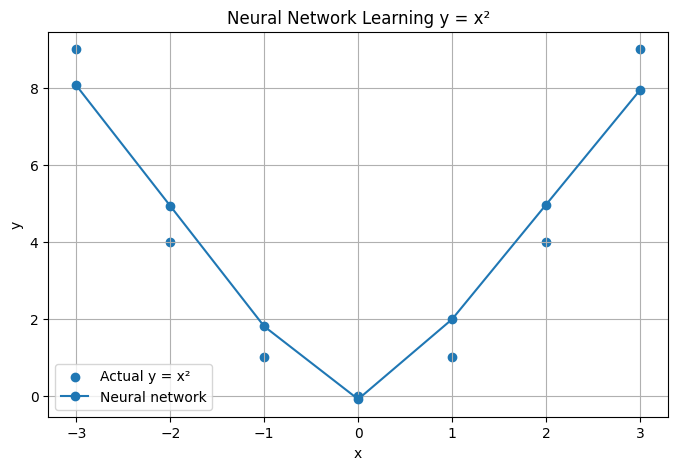

In [25]:
#graph
import matplotlib.pyplot as plt

# Actual training data
x_values = x.detach().numpy().flatten()
y_actual = y.detach().numpy().flatten()

# Network predictions
with torch.no_grad():
    y_pred = model(x).numpy().flatten()

plt.figure(figsize=(8, 5))

plt.scatter(x_values, y_actual, label="Actual y = x²")
plt.plot(x_values, y_pred, marker="o", label="Neural network")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Neural Network Learning y = x²")
plt.legend()
plt.grid(True)

plt.show()